In [1]:
!pip3 install pandas numpy matplotlib seaborn scipy scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


# VEX Robotics National Tournament Qualification Ranking Analysis

## Research Question
**"How well do WP, AP, and SP actually explain qualification rankings, and is the current tiebreaker system statistically justified?"**

## Sub Question 2: Autonomous Points (AP)
**"Among teams tied on WP, does AP effectively differentiate qualification rankings?"**

Methods used:
- **WP Tie Group Identification**
- **Pearson Correlation (within WP ties)**
- **Rank Accuracy Analysis**
- **One-Way ANOVA**

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load data
df = pd.read_csv('VEX Data - Data Set.csv')

print(f'Total teams: {len(df)}')
print()
df.head(10)

Total teams: 44



,Team,Rank,WP,AP,SP,OPR,DPR,CCWM,W,L,T
0,1100A,1,19,80,125,66.8,-2.0,68.8,8,0,0
1,30410V,2,17,70,142,56.2,-4.2,60.4,8,0,0
2,1740X,3,16,70,114,50.9,-6.2,57.1,7,1,0
3,30597E,4,16,60,164,45.9,-9.6,55.6,8,0,0
4,3723A,5,14,60,139,23.1,8.3,14.8,6,2,0
5,30597J,6,14,50,159,51.4,9.5,41.8,6,2,0
6,14533A,7,12,55,188,44.3,9.2,35.1,6,2,0
7,6724T,8,12,40,190,33.7,26.2,7.6,6,2,0
8,30597X,9,11,50,212,39.2,12.6,26.5,5,3,0
9,3723X,10,11,40,164,21.9,25.3,-3.4,5,3,0


In [4]:
df[['Rank', 'WP', 'AP', 'SP']].describe().round(2)

,Rank,WP,AP,SP
count,44.00,44.00,44.00,44.00
mean,22.50,8.50,38.30,161.07
std,12.85,3.90,16.74,37.15
min,1.00,0.00,5.00,72.00
25%,11.75,6.00,28.75,137.25
50%,22.50,8.00,40.00,169.00
75%,33.25,10.25,50.00,186.50
max,44.00,19.00,80.00,232.00


## Step 1: Overall Pearson Correlation (AP vs Rank)

Before focusing on tie groups, we first check whether AP has any overall relationship with Rank across all teams.

- r = -1: perfect negative relationship
- r = 0: no relationship
- r = 1: perfect positive relationship

We expect a **negative** r since higher AP should produce a lower (better) rank number.

In [5]:
# Pearson Correlation: AP vs Rank (all teams)
r_ap, p_ap = stats.pearsonr(df['AP'], df['Rank'])

print('=== Pearson Correlation: AP vs Rank (All Teams) ===')
print(f'r = {r_ap:.4f}')
print(f'p-value = {p_ap:.6f}')
print()

if p_ap < 0.05:
    print('Result: Statistically SIGNIFICANT (p < 0.05)')
else:
    print('Result: NOT statistically significant (p > 0.05)')

print()
print('Interpretation:')
if abs(r_ap) >= 0.7:
    print(f'Strong correlation (r = {r_ap:.4f}): AP is a strong predictor of ranking.')
elif abs(r_ap) >= 0.4:
    print(f'Moderate correlation (r = {r_ap:.4f}): AP partially explains ranking.')
else:
    print(f'Weak correlation (r = {r_ap:.4f}): AP alone has limited predictive power overall.')

=== Pearson Correlation: AP vs Rank (All Teams) ===
r = -0.7926
p-value = 0.000000

Result: Statistically SIGNIFICANT (p < 0.05)

Interpretation:
Strong correlation (r = -0.7926): AP is a strong predictor of ranking.


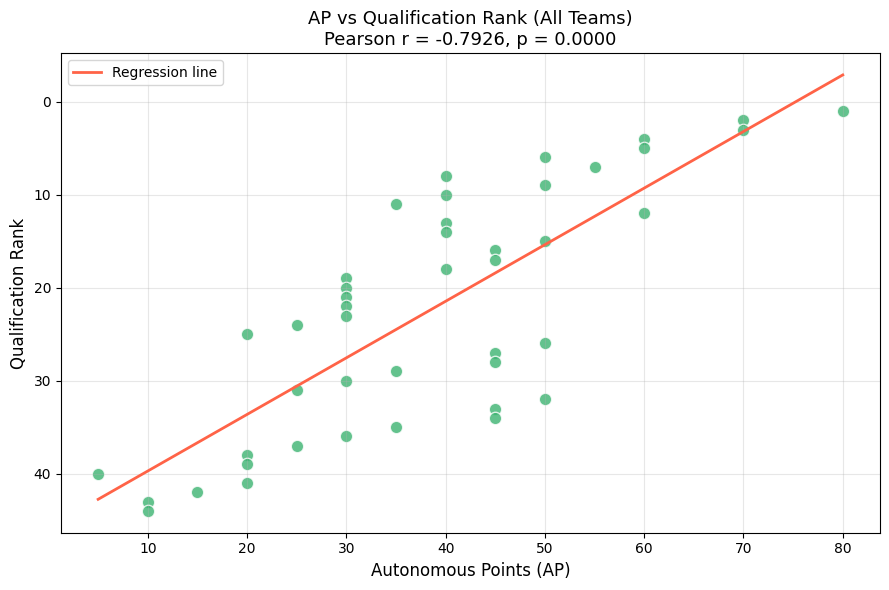

Figure saved.


In [6]:
# Visualization: AP vs Rank scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['AP'], df['Rank'], color='mediumseagreen', edgecolors='white', s=80, alpha=0.8)

m, b = np.polyfit(df['AP'], df['Rank'], 1)
x_line = np.linspace(df['AP'].min(), df['AP'].max(), 100)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label='Regression line')

ax.set_xlabel('Autonomous Points (AP)', fontsize=12)
ax.set_ylabel('Qualification Rank', fontsize=12)
ax.set_title(f'AP vs Qualification Rank (All Teams)\nPearson r = {r_ap:.4f}, p = {p_ap:.4f}', fontsize=13)
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sub2_pearson_ap_rank.png', dpi=150)
plt.show()
print('Figure saved.')

## Step 2: WP Tie Group Analysis

AP's real function is as a **tiebreaker**, so it only matters when multiple teams share the same WP.

Here we:
1. Identify all WP values shared by 2+ teams
2. Within each tie group, check whether AP correctly orders teams by Rank

If AP is a valid tiebreaker, teams with higher AP should consistently receive a better (lower) rank number within the same WP group.

In [7]:
# Identify WP tie groups (groups with 2+ teams sharing the same WP)
wp_counts = df['WP'].value_counts()
tied_wp_values = wp_counts[wp_counts >= 2].index.tolist()

df_tied = df[df['WP'].isin(tied_wp_values)].copy()

print(f'Total WP values that appear: {df["WP"].nunique()}')
print(f'WP values with 2+ teams tied: {len(tied_wp_values)}')
print(f'Teams involved in WP ties: {len(df_tied)} out of {len(df)}')
print()
print('WP tie group sizes:')
print(wp_counts[wp_counts >= 2].sort_index(ascending=False))

Total WP values that appear: 14
WP values with 2+ teams tied: 9
Teams involved in WP ties: 39 out of 44

WP tie group sizes:
WP
16     2
14     2
12     2
11     3
10     2
8     11
7      6
6      9
2      2
Name: count, dtype: int64


In [8]:
# Within each WP tie group, compute AP ordering accuracy (pairwise)
group_results = []

for wp_val in sorted(tied_wp_values, reverse=True):
    group = df[df['WP'] == wp_val].sort_values('Rank')
    n = len(group)
    ap_vals = group['AP'].values
    rank_vals = group['Rank'].values

    correct = 0
    total_pairs = 0
    for i in range(n):
        for j in range(i + 1, n):
            total_pairs += 1
            if ap_vals[i] > ap_vals[j]:
                correct += 1
            elif ap_vals[i] == ap_vals[j]:
                correct += 0.5

    accuracy = correct / total_pairs if total_pairs > 0 else np.nan
    group_results.append({
        'WP': wp_val,
        'n_teams': n,
        'AP_mean': round(group['AP'].mean(), 2),
        'AP_std': round(group['AP'].std(), 2),
        'pair_accuracy': round(accuracy, 4)
    })

results_df = pd.DataFrame(group_results)
print('=== AP Ordering Accuracy Within WP Tie Groups ===')
print(results_df.to_string(index=False))
print()
print(f'Mean pair accuracy across all tie groups: {results_df["pair_accuracy"].mean():.4f}')

=== AP Ordering Accuracy Within WP Tie Groups ===
 WP  n_teams  AP_mean  AP_std  pair_accuracy
 16        2    65.00    7.07         1.0000
 14        2    55.00    7.07         1.0000
 12        2    47.50   10.61         1.0000
 11        3    41.67    7.64         1.0000
 10        2    50.00   14.14         1.0000
  8       11    34.09    9.44         0.9000
  7        6    38.33    9.83         0.9667
  6        9    30.56   14.67         0.9722
  2        2    12.50    3.54         1.0000

Mean pair accuracy across all tie groups: 0.9821


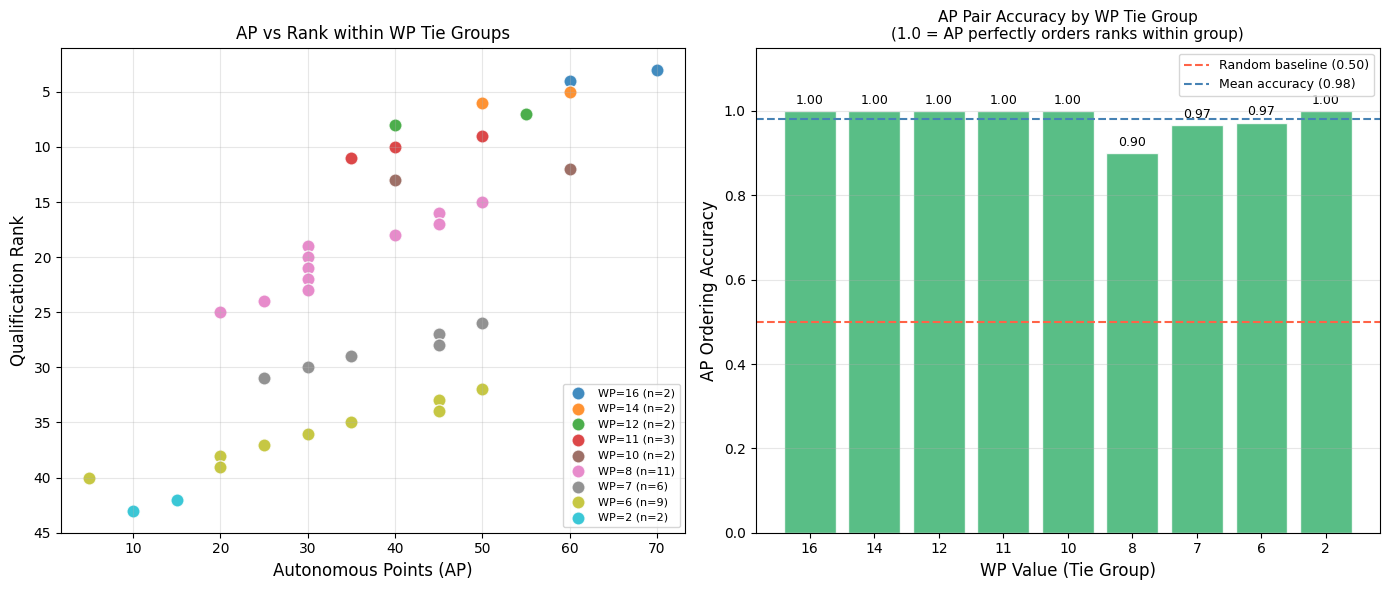

Figure saved.


In [9]:
# Visualization: AP within WP tie groups
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(tied_wp_values)))
for idx, wp_val in enumerate(sorted(tied_wp_values, reverse=True)):
    group = df_tied[df_tied['WP'] == wp_val]
    axes[0].scatter(group['AP'], group['Rank'],
                    color=colors[idx], edgecolors='white', s=90, alpha=0.85,
                    label=f'WP={wp_val} (n={len(group)})')

axes[0].set_xlabel('Autonomous Points (AP)', fontsize=12)
axes[0].set_ylabel('Qualification Rank', fontsize=12)
axes[0].set_title('AP vs Rank within WP Tie Groups', fontsize=12)
axes[0].invert_yaxis()
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(results_df['WP'].astype(str), results_df['pair_accuracy'],
                   color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axhline(y=0.5, color='tomato', linewidth=1.5, linestyle='--', label='Random baseline (0.50)')
axes[1].axhline(y=results_df['pair_accuracy'].mean(), color='steelblue',
                linewidth=1.5, linestyle='--',
                label=f'Mean accuracy ({results_df["pair_accuracy"].mean():.2f})')

for bar, val in zip(bars, results_df['pair_accuracy']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xlabel('WP Value (Tie Group)', fontsize=12)
axes[1].set_ylabel('AP Ordering Accuracy', fontsize=12)
axes[1].set_title('AP Pair Accuracy by WP Tie Group\n(1.0 = AP perfectly orders ranks within group)', fontsize=11)
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sub2_ap_tiebreaker_analysis.png', dpi=150)
plt.show()
print('Figure saved.')

## Step 3: Pearson Correlation (AP vs Rank Within Tied Teams)

Compute the correlation between AP and Rank using **only the subset of teams involved in WP ties**.

This directly tests AP's effectiveness as a tiebreaker.

In [10]:
# Pearson Correlation: AP vs Rank (WP-tied teams only)
r_tied, p_tied = stats.pearsonr(df_tied['AP'], df_tied['Rank'])

print('=== Pearson Correlation: AP vs Rank (WP-Tied Teams Only) ===')
print(f'n = {len(df_tied)} teams in WP ties')
print(f'r = {r_tied:.4f}')
print(f'p-value = {p_tied:.6f}')
print()

if p_tied < 0.05:
    print('Result: Statistically SIGNIFICANT (p < 0.05)')
else:
    print('Result: NOT statistically significant (p > 0.05)')

print()
print('Interpretation:')
if abs(r_tied) >= 0.7:
    print(f'Strong correlation (r = {r_tied:.4f}): AP is an effective tiebreaker.')
elif abs(r_tied) >= 0.4:
    print(f'Moderate correlation (r = {r_tied:.4f}): AP partially resolves ties.')
else:
    print(f'Weak correlation (r = {r_tied:.4f}): AP has limited effectiveness as a tiebreaker.')

=== Pearson Correlation: AP vs Rank (WP-Tied Teams Only) ===
n = 39 teams in WP ties
r = -0.7302
p-value = 0.000000

Result: Statistically SIGNIFICANT (p < 0.05)

Interpretation:
Strong correlation (r = -0.7302): AP is an effective tiebreaker.


## Step 4: One-Way ANOVA (AP Differences Across Rank Groups)

**One-Way ANOVA** tests whether the mean AP differs significantly across three rank groups (Top, Mid, Bottom).

- F-statistic: larger values indicate greater differences between group means relative to within-group variance
- p < 0.05: at least one group has a significantly different AP mean

If ANOVA is significant, it means AP levels are not equal across rank groups, supporting AP's role as a valid ranking criterion.

In [11]:
# One-Way ANOVA: AP across Rank Groups
df['Rank_Group'] = pd.cut(df['Rank'], bins=[0, 15, 30, 44],
                           labels=['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)'])

top = df[df['Rank_Group'] == 'Top (1-15)']['AP']
mid = df[df['Rank_Group'] == 'Mid (16-30)']['AP']
bottom = df[df['Rank_Group'] == 'Bottom (31-44)']['AP']

print('=== Descriptive Statistics: AP by Rank Group ===')
print(f'Top group AP    — mean: {top.mean():.2f}, std: {top.std():.2f}')
print(f'Mid group AP    — mean: {mid.mean():.2f}, std: {mid.std():.2f}')
print(f'Bottom group AP — mean: {bottom.mean():.2f}, std: {bottom.std():.2f}')
print()

f_stat, p_anova = stats.f_oneway(top, mid, bottom)
print('=== One-Way ANOVA: AP across Rank Groups ===')
print(f'F-statistic = {f_stat:.4f}')
print(f'p-value     = {p_anova:.6f}')
print()
if p_anova < 0.05:
    print('Result: Statistically SIGNIFICANT — AP mean differs across rank groups (p < 0.05)')
else:
    print('Result: NOT statistically significant (p > 0.05)')

=== Descriptive Statistics: AP by Rank Group ===
Top group AP    — mean: 53.33, std: 13.32
Mid group AP    — mean: 35.33, std: 8.96
Bottom group AP — mean: 25.36, std: 14.07

=== One-Way ANOVA: AP across Rank Groups ===
F-statistic = 19.4630
p-value     = 0.000001

Result: Statistically SIGNIFICANT — AP mean differs across rank groups (p < 0.05)


/var/folders/zp/w_vsmpq54wzf0vrcktvxwzb40000gn/T/ipykernel_22405/3734328340.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(groups_data, labels=group_labels, patch_artist=True)


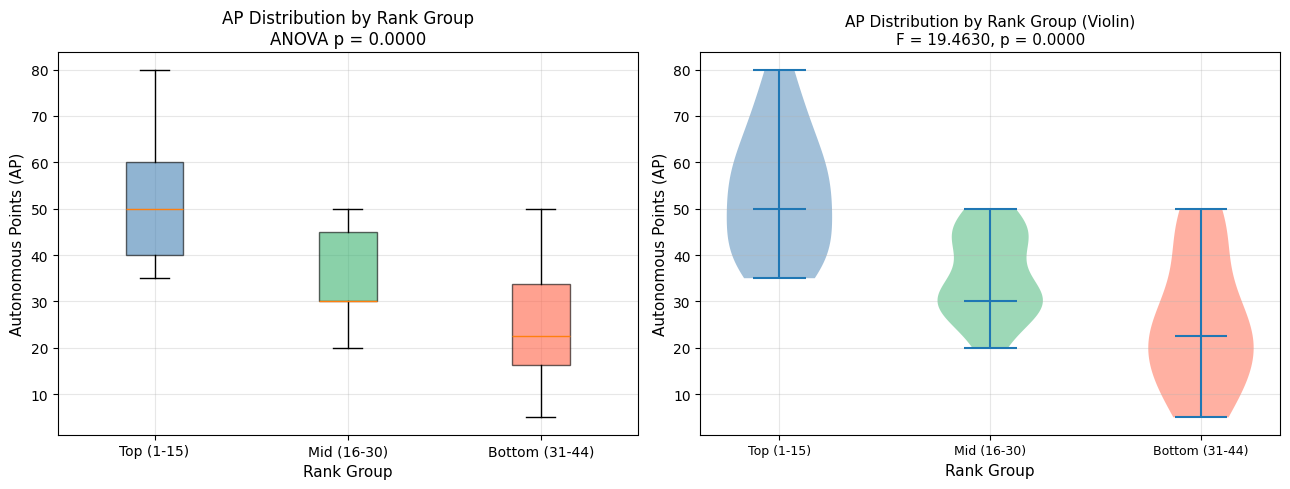

Figure saved.


In [12]:
# Visualization: AP distribution by rank groups
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

group_labels = ['Top (1-15)', 'Mid (16-30)', 'Bottom (31-44)']
group_colors = ['steelblue', 'mediumseagreen', 'tomato']
groups_data = [df[df['Rank_Group'] == g]['AP'].values for g in group_labels]

bp = axes[0].boxplot(groups_data, labels=group_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], group_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].set_xlabel('Rank Group', fontsize=11)
axes[0].set_ylabel('Autonomous Points (AP)', fontsize=11)
axes[0].set_title(f'AP Distribution by Rank Group\nANOVA p = {p_anova:.4f}', fontsize=12)
axes[0].grid(True, alpha=0.3)

parts = axes[1].violinplot(groups_data, positions=[1, 2, 3], showmedians=True)
for pc, color in zip(parts['bodies'], group_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)

axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(group_labels, fontsize=9)
axes[1].set_xlabel('Rank Group', fontsize=11)
axes[1].set_ylabel('Autonomous Points (AP)', fontsize=11)
axes[1].set_title(f'AP Distribution by Rank Group (Violin)\nF = {f_stat:.4f}, p = {p_anova:.4f}', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sub2_ap_rank_groups.png', dpi=150)
plt.show()
print('Figure saved.')

## Sub Question 2: Summary

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Pearson r (all teams) | -0.7926 | AP and Rank relationship across all teams |
| Pearson r (WP-tied teams) | -0.7302 | AP effectiveness as tiebreaker |
| Pair Accuracy (mean) | 0.9821 | % of within-group AP orderings that are correct |
| ANOVA F-statistic | 19.4630 | Between-group vs within-group AP variance |
| ANOVA p-value | 0.000001 | Significance of AP differences across rank groups |

**Key Finding:**
AP serves as the first tiebreaker in VEX qualification rankings. This analysis examines whether AP meaningfully distinguishes teams within WP tie groups, providing statistical evidence for or against AP's validity as a tiebreaker criterion.